# peak27535_Reversed CSM-entropy — 10% mut-rate SEAM run (100k lib, K=50)
Per-cluster × per-position base-frequency entropy of the mutant library, the SEAM CSM (Cluster-State Map) view. Self-consistent **10% mut-rate** run: `foregrounds` ← `ism` ← `mutagenesis_lib`. Rows ordered by per-cluster median predicted activity (high→low); the WT's cluster row is marked in red, with a median-activity barplot along the right edge.

## WT reference — before the CSM
Three attribution logos for the WT (unmutated) sequence: its **seq attribution map**, its **cluster average** (mean map of the cluster the WT falls into), and its **foreground** (cluster avg − scaled background). Then a 2D view of all cluster averages: x = mean-prediction difference from the WT, y = cosine similarity of the cluster's average attribution map to the WT map. All from the self-consistent **10% mut-rate** run (`foregrounds` ← `ism` ← `mutagenesis_lib`).

5 WT annotations: [('de-novo', 12, 31), ('A', 71, 96), ('B', 101, 123), ('C', 126, 139), ('D', 139, 157)]


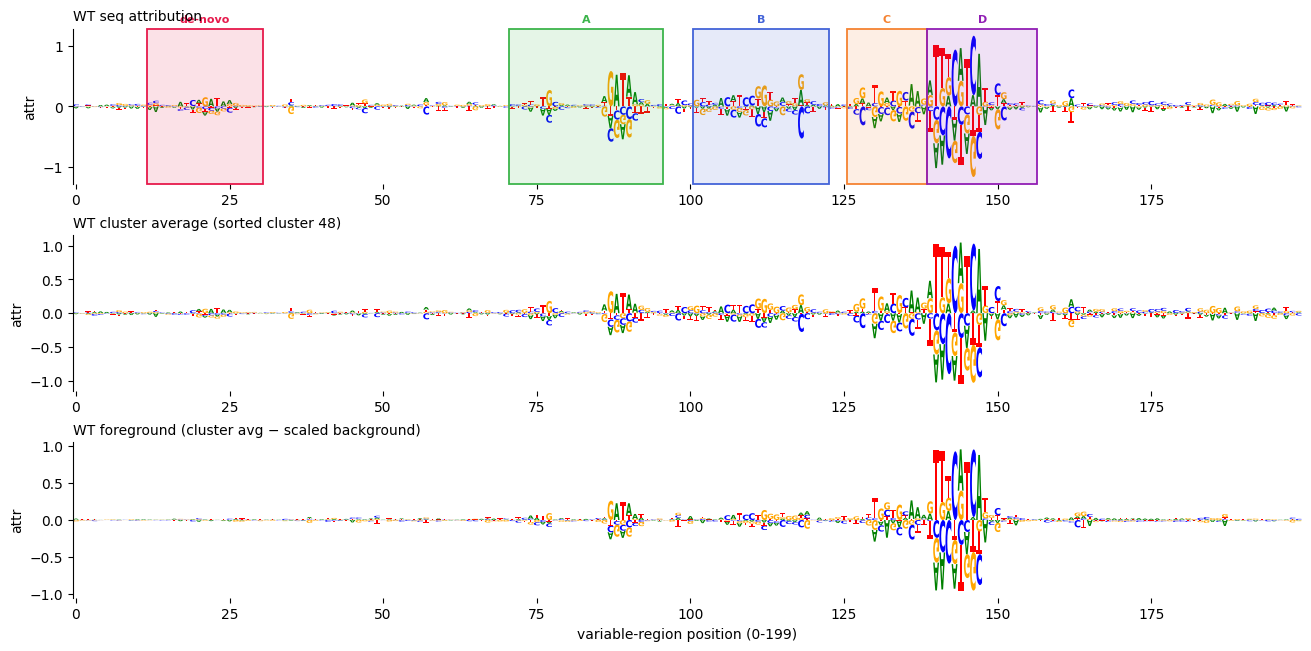

In [252]:
# WT reference panels (before the CSM): WT-seq attribution, WT cluster average, WT foreground.
# The WT-seq attribution map is overlaid with the motif annotations drawn in situate
# (peak27_clusters unit c01_m00 = the WT ref), ordered left->right: first = "de-novo", then A, B, C, D.
import numpy as np, sys, csv, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Rectangle
sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

def strip_spines(ax):
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)

# 10% mut-rate run (primary): foregrounds <- ism <- mutagenesis_lib, all self-consistent.
FG = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds/peak27535_Reversed")
wt_att    = np.load(FG / "wt_attribution.npy")       # (200,4) attribution of the WT (unmutated) seq
ref_avg   = np.load(FG / "ref_cluster_avg.npy")      # (200,4) mean attribution of the cluster the WT falls into
fg_scaled = np.load(FG / "foreground_scaled.npy")    # (200,4) ref_cluster_avg - bg_scale * background
ref_idx   = int(np.load(FG / "ref_cluster_idx.npy"))

# WT motif annotations exported from situate; sort left->right, label first "de-novo" then A,B,C,D,...
ANNOT_CSV = Path("/grid/koo/home/pmantill/projects/situate/edits.csv")
WT_KEY    = "SEAM:K562:c01_m00:foreground_scaled"
_spans = sorted(([int(r["start"]), int(r["end"])] for r in csv.DictReader(open(ANNOT_CSV))
                 if r["sequence_name"] == WT_KEY), key=lambda se: se[0])
_names = ["de-novo"] + list("ABCDEFGHIJKLMNOP")
annots = [(_names[i], s, e) for i, (s, e) in enumerate(_spans)]     # (label, start, end)
_apal  = ["#e6194B", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
          "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990"]
print(f"{len(annots)} WT annotations:", annots)

def draw_annotations(ax):
    tr = ax.get_xaxis_transform()                    # x in data coords, y in axes fraction
    for i, (lab, s, e) in enumerate(annots):
        c = _apal[i]
        ax.axvspan(s - 0.5, e - 0.5, color=c, alpha=0.13, lw=0)
        ax.add_patch(Rectangle((s - 0.5, 0), (e - s), 1, transform=tr, fill=False,
                               edgecolor=c, lw=1.3, zorder=5, clip_on=False))
        ax.text((s + e) / 2 - 0.5, 1.03, lab, transform=tr, ha="center", va="bottom",
                fontsize=8, color=c, fontweight="bold", clip_on=False)

panels = [("WT seq attribution", wt_att),
          (f"WT cluster average (sorted cluster {ref_idx})", ref_avg),
          ("WT foreground (cluster avg − scaled background)", fg_scaled)]

fig, axes = plt.subplots(3, 1, figsize=(13, 6.4), constrained_layout=True)
for ax, (title, arr) in zip(axes, panels):
    fast_logo(arr.astype(np.float32), ax)
    strip_spines(ax)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel("attr")
draw_annotations(axes[0])                            # annotations on the WT seq attribution map
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

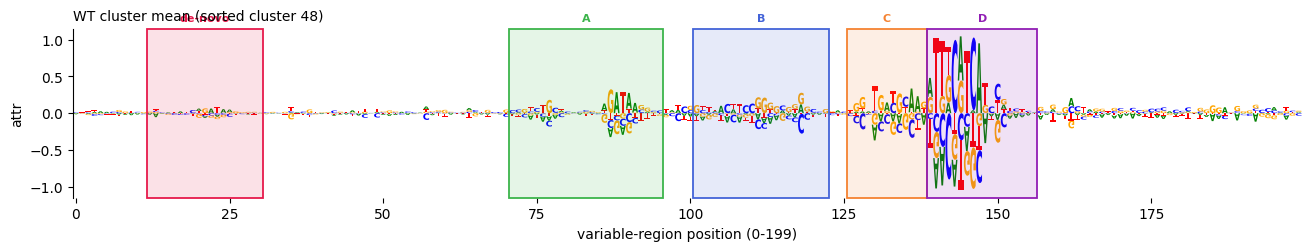

In [253]:
# WT cluster mean — single logo (mean attribution map of the cluster the WT falls into),
# overlaid with the same WT motif annotations (de-novo, A, B, C, D) from the cell above.
fig, ax = plt.subplots(figsize=(13, 2.4), constrained_layout=True)
fast_logo(ref_avg.astype(np.float32), ax)
strip_spines(ax)
draw_annotations(ax)
ax.set_title(f"WT cluster mean (sorted cluster {ref_idx})", fontsize=10, loc="left")
ax.set_ylabel("attr")
ax.set_xlabel("variable-region position (0-199)")
plt.show()

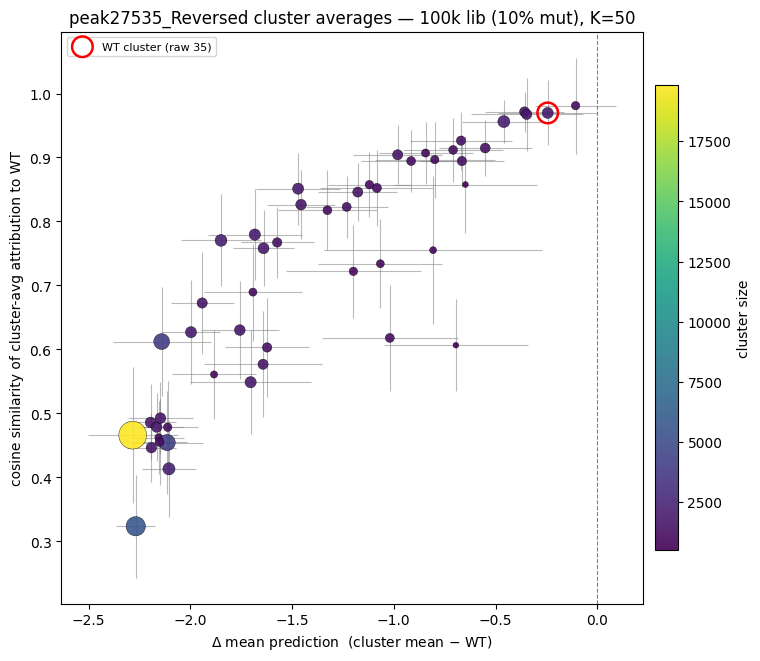

In [254]:
# Cluster averages in 2D (before the CSM): x = mean-prediction difference from the WT seq,
# y = cosine similarity of the cluster's average attribution map to the WT-seq attribution map.
# Crossed error bars = within-cluster spread (std of per-seq Δpred on x, std of per-seq cosine on y).
import numpy as np, h5py, matplotlib.pyplot as plt
from pathlib import Path

base = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
FG   = base / "foregrounds/peak27535_Reversed"
labels = np.load(FG / "cluster_labels.npy")               # raw cluster ids, aligned to ism order
with h5py.File(base / "ism/peak27535_Reversed.h5") as f:
    att   = f["ism_centered"][:]                          # (100000,200,4), att[0] = WT map
    preds = f["predictions"][:]                           # (100000,),      preds[0] = WT prediction

wt_att  = att[0].ravel()
wt_unit = wt_att / np.linalg.norm(wt_att)
wt_pred = preds[0]

# per-sequence quantities (vectorized) for the error bars
flat      = att.reshape(len(att), -1)                     # (N, 800)
cos_all   = (flat @ wt_unit) / np.linalg.norm(flat, axis=1)   # per-seq cosine to WT
dpred_all = preds - wt_pred                                    # per-seq Δ prediction

uids  = np.unique(labels)
sizes = np.array([(labels == c).sum() for c in uids])
x   = np.array([dpred_all[labels == c].mean() for c in uids])                 # cluster mean Δpred
xer = np.array([dpred_all[labels == c].std()  for c in uids])
means = np.stack([att[labels == c].mean(0) for c in uids]).reshape(len(uids), -1)
y   = (means @ wt_unit) / np.linalg.norm(means, axis=1)                       # cosine of cluster-avg map to WT
yer = np.array([cos_all[labels == c].std() for c in uids])                    # within-cluster spread
ref_raw = labels[0]                                       # raw cluster the WT (row 0) falls into

fig, ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
ax.errorbar(x, y, xerr=xer, yerr=yer, fmt="none", ecolor="grey",
            elinewidth=0.8, alpha=0.55, capsize=0, zorder=1)
sc = ax.scatter(x, y, s=np.clip(sizes / 30, 8, 400), c=sizes, cmap="viridis",
                alpha=0.9, edgecolor="k", linewidth=0.3, zorder=2)
m = uids == ref_raw
ax.scatter(x[m], y[m], s=220, facecolor="none", edgecolor="red", linewidth=1.8,
           zorder=3, label=f"WT cluster (raw {int(ref_raw)})")
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel(r"$\Delta$ mean prediction  (cluster mean $-$ WT)")
ax.set_ylabel("cosine similarity of cluster-avg attribution to WT")
ax.set_title(f"peak27535_Reversed cluster averages — 100k lib (10% mut), K={len(uids)}")
fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label="cluster size")
ax.legend(loc="best", fontsize=8)
plt.show()

In [255]:
# load peak27535_Reversed + its 100k / K=50 SEAM run, compute CSM entropy (rows ordered by median activity)
import numpy as np, h5py, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

R    = Path("/grid/koo/home/pmantill/projects/SEAM_validate")
FG   = R / "results/single_seq/foregrounds/peak27535_Reversed"        # 100k library, K=50, 10% mut-rate (primary run)
MUT  = R / "results/single_seq/mutagenesis_lib/peak27535_Reversed.h5"  # shared 100k mutant one-hots (10% mut-rate)
ISM  = R / "results/single_seq/ism/peak27535_Reversed.h5"             # per-mutant predictions (activity)
VAR_START, VAR_END = 15, 215                                          # variable region within 230 bp insert

labels = np.load(FG / "cluster_labels.npy")                           # (100000,) raw cluster ids
with h5py.File(MUT) as f:
    seqs = f["sequences"][: len(labels)]                             # (N,230,4), aligned to labels
with h5py.File(ISM) as f:
    preds = f["predictions"][: len(labels)]                         # (N,) predicted activity, aligned to labels
wt_cluster = int(labels[0])                                          # cluster the WT (row 0) falls into
print(f"{len(labels)} seqs, {len(np.unique(labels))} clusters | WT in raw cluster {wt_cluster}")

def csm_entropy(seqs_oh, labels, preds):
    """(N,230,4) one-hots + labels + preds -> entropy (n_clusters,200), median activity, size,
    and the raw cluster id per row. Rows ordered by descending per-cluster median activity."""
    s = seqs_oh[:, VAR_START:VAR_END, :].astype(np.float32)           # (N,200,4)
    clusters = np.unique(labels)
    ent     = np.zeros((len(clusters), s.shape[1]), np.float32)
    sizes   = np.zeros(len(clusters), int)
    med_act = np.zeros(len(clusters), np.float32)
    for i, c in enumerate(clusters):
        m = labels == c
        sizes[i]   = m.sum()
        med_act[i] = np.median(preds[m])
        freqs = s[m].mean(0).T                                       # (4,L) mean one-hot = base frequency
        with np.errstate(divide="ignore", invalid="ignore"):
            e = -np.sum(freqs * np.log2(freqs + 1e-10), axis=0)
        ent[i] = np.nan_to_num(e)
    order = np.argsort(-med_act)                                     # highest median activity first
    return ent[order], sizes[order], med_act[order], clusters[order]

ent, sizes, med_act, clusters_ord = csm_entropy(seqs, labels, preds)
wt_row = int(np.where(clusters_ord == wt_cluster)[0][0])            # CSM row index of the WT's cluster
wt_pred = float(preds[0])
print(f"WT cluster {wt_cluster} -> CSM row {wt_row}; WT activity = {wt_pred:.3f}")

100000 seqs, 50 clusters | WT in raw cluster 35
WT cluster 35 -> CSM row 1; WT activity = 1.765


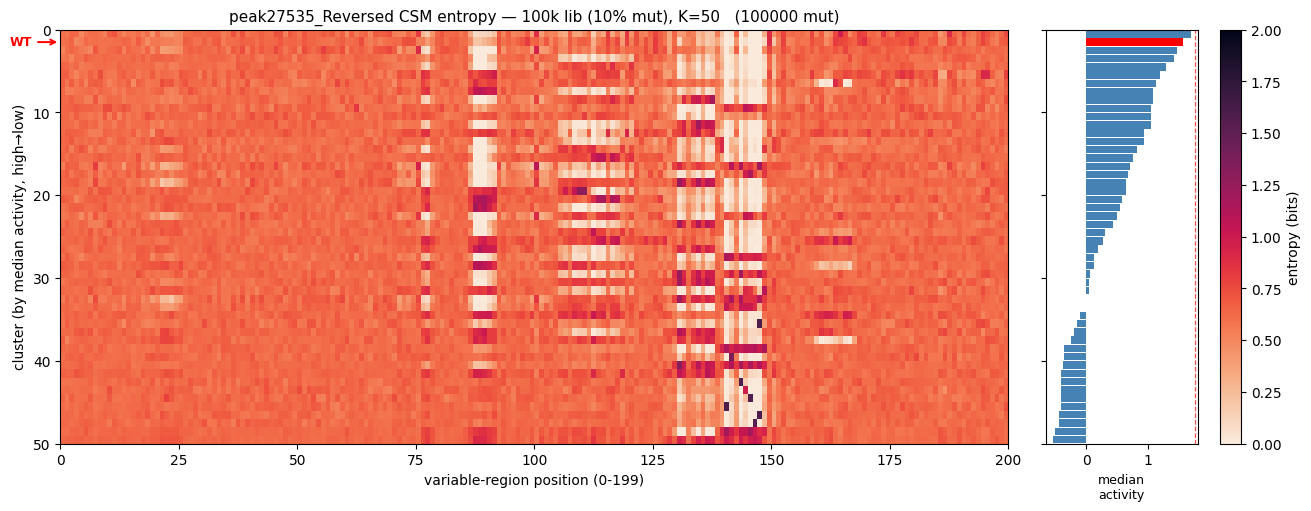

In [256]:
# CSM entropy heatmap (rocket_r, 0-2 bits) + right-edge barplot of per-cluster median activity.
# Rows ordered by median activity (descending); the WT's cluster row is marked in red.
fig = plt.figure(figsize=(13, 5), constrained_layout=True)
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 0.16], wspace=0.03)
ax  = fig.add_subplot(gs[0, 0])
axb = fig.add_subplot(gs[0, 1], sharey=ax)

nrows = ent.shape[0]
im = ax.imshow(ent, aspect="auto", cmap=sns.color_palette("rocket_r", as_cmap=True),
               vmin=0, vmax=2, interpolation="nearest",
               extent=[0, ent.shape[1], nrows, 0])
ax.set_title(f"peak27535_Reversed CSM entropy — 100k lib (10% mut), K={nrows}   ({int(sizes.sum())} mut)", fontsize=11)
ax.set_ylabel("cluster (by median activity, high→low)")
ax.set_xlabel("variable-region position (0-199)")

# mark the WT's cluster row with a red arrow on the left margin (no data occlusion)
ax.annotate("WT", xy=(0, wt_row + 0.5), xytext=(-20, 0), textcoords="offset points",
            va="center", ha="right", color="red", fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="red", lw=1.4))

# right barplot: per-cluster median activity, aligned to heatmap rows (WT bar red)
ypos   = np.arange(nrows) + 0.5
colors = ["red" if i == wt_row else "steelblue" for i in range(nrows)]
axb.barh(ypos, med_act, height=0.9, color=colors)
axb.axvline(wt_pred, color="red", lw=0.9, ls="--", alpha=0.7)          # WT activity reference
axb.set_ylim(nrows, 0)
axb.set_xlabel("median\nactivity", fontsize=9)
axb.tick_params(labelleft=False)
axb.margins(y=0)

fig.colorbar(im, ax=[ax, axb], fraction=0.03, pad=0.02, location="right", label="entropy (bits)")
plt.show()

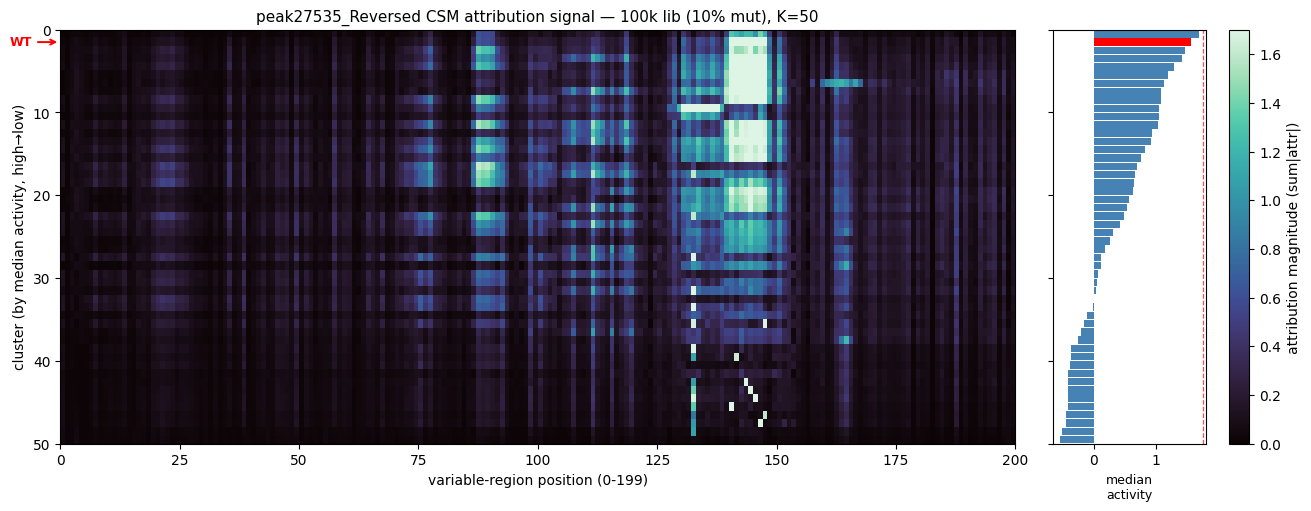

In [257]:
# CSM colored by ATTRIBUTION SIGNAL — same rows / same order as the entropy CSM (by median activity).
# Per-cluster, per-position signal = total magnitude of the cluster-average attribution map: sum_ch |mean attr|.
sig = np.zeros((len(clusters_ord), att.shape[1]), np.float32)
for i, c in enumerate(clusters_ord):
    sig[i] = np.abs(att[labels == c].mean(0)).sum(1)          # (200,) attribution magnitude per position

fig = plt.figure(figsize=(13, 5), constrained_layout=True)
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 0.16], wspace=0.03)
ax  = fig.add_subplot(gs[0, 0])
axb = fig.add_subplot(gs[0, 1], sharey=ax)

nrows = sig.shape[0]
im = ax.imshow(sig, aspect="auto", cmap=sns.color_palette("mako", as_cmap=True),
               vmin=0, vmax=np.percentile(sig, 99), interpolation="nearest",
               extent=[0, sig.shape[1], nrows, 0])
ax.set_title(f"peak27535_Reversed CSM attribution signal — 100k lib (10% mut), K={nrows}", fontsize=11)
ax.set_ylabel("cluster (by median activity, high→low)")
ax.set_xlabel("variable-region position (0-199)")

# mark the WT's cluster row with a red arrow on the left margin (no data occlusion)
ax.annotate("WT", xy=(0, wt_row + 0.5), xytext=(-20, 0), textcoords="offset points",
            va="center", ha="right", color="red", fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="red", lw=1.4))

# right barplot: per-cluster median activity, aligned to heatmap rows (WT bar red)
ypos   = np.arange(nrows) + 0.5
colors = ["red" if i == wt_row else "steelblue" for i in range(nrows)]
axb.barh(ypos, med_act, height=0.9, color=colors)
axb.axvline(wt_pred, color="red", lw=0.9, ls="--", alpha=0.7)          # WT activity reference
axb.set_ylim(nrows, 0)
axb.set_xlabel("median\nactivity", fontsize=9)
axb.tick_params(labelleft=False)
axb.margins(y=0)

fig.colorbar(im, ax=[ax, axb], fraction=0.03, pad=0.02, location="right",
             label="attribution magnitude (sum|attr|)")
plt.show()

CSM row 1 (sorted by median activity, high→low)  ->  raw cluster 35
  size                  = 1885
  cosine to WT          = 0.9697
  functional diff (Δpred) = -0.2437   (cluster mean 1.5215 vs WT 1.7651)
  random member index   = 22119  (pred 1.7511)


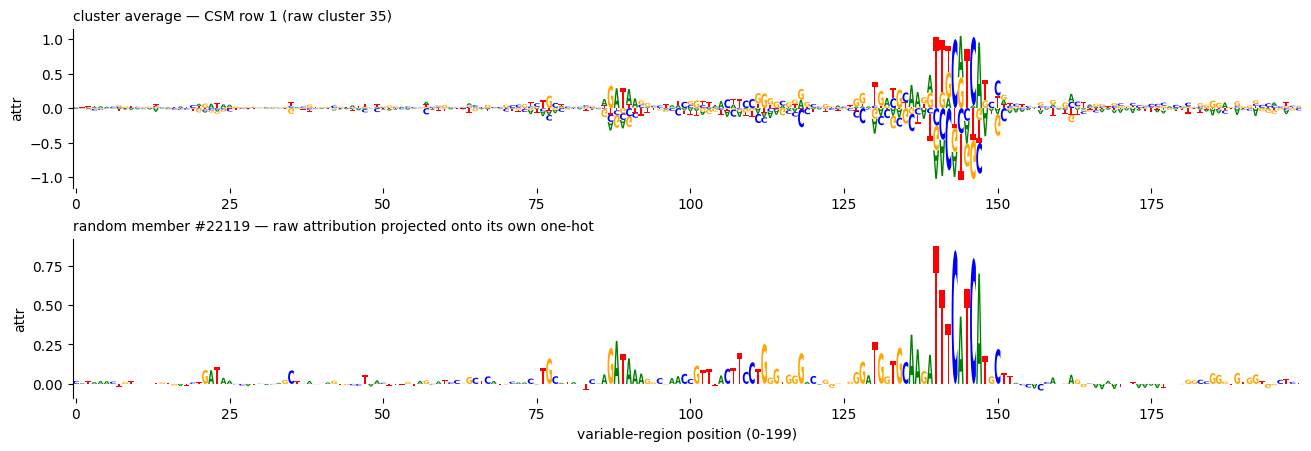

In [258]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 1   # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

CSM row 7 (sorted by median activity, high→low)  ->  raw cluster 11
  size                  = 1353
  cosine to WT          = 0.8945
  functional diff (Δpred) = -0.6653   (cluster mean 1.0998 vs WT 1.7651)
  random member index   = 60708  (pred 0.8087)


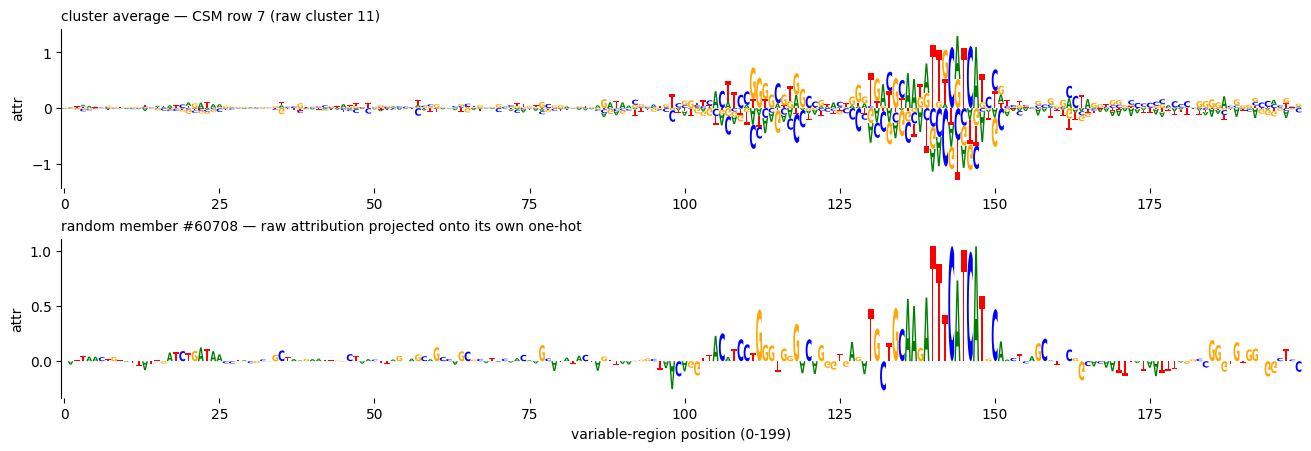

In [259]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 7  # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show() 

CSM row 4 (sorted by median activity, high→low)  ->  raw cluster 4
  size                  = 2236
  cosine to WT          = 0.9562
  functional diff (Δpred) = -0.4593   (cluster mean 1.3058 vs WT 1.7651)
  random member index   = 45529  (pred 1.4610)


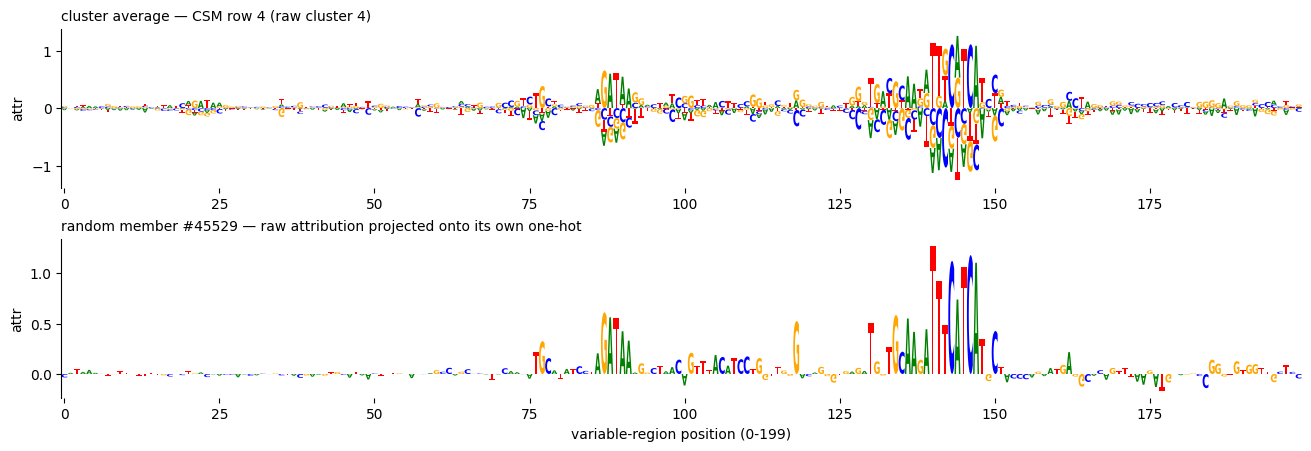

In [260]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 4   # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

CSM row 11 (sorted by median activity, high→low)  ->  raw cluster 15
  size                  = 1225
  cosine to WT          = 0.9119
  functional diff (Δpred) = -0.7086   (cluster mean 1.0565 vs WT 1.7651)
  random member index   = 41270  (pred 1.1828)


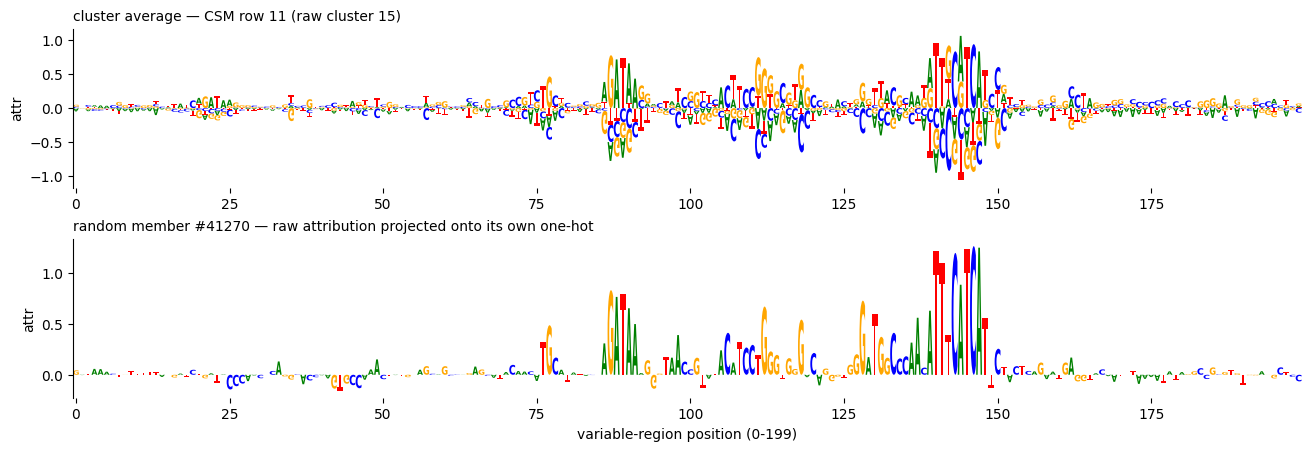

In [261]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 11   # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

CSM row 9 (sorted by median activity, high→low)  ->  raw cluster 13
  size                  = 504
  cosine to WT          = 0.6066
  functional diff (Δpred) = -0.6950   (cluster mean 1.0701 vs WT 1.7651)
  random member index   = 64344  (pred 0.6565)


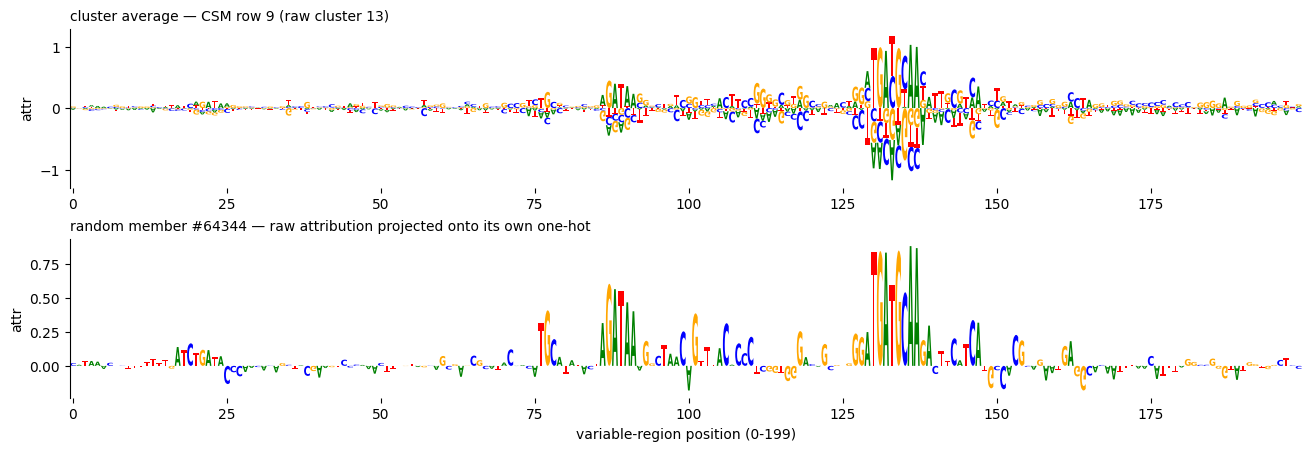

In [262]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 9  # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show() 

CSM row 20 (sorted by median activity, high→low)  ->  raw cluster 25
  size                  = 1578
  cosine to WT          = 0.8460
  functional diff (Δpred) = -1.1772   (cluster mean 0.5879 vs WT 1.7651)
  random member index   = 87735  (pred 0.4361)


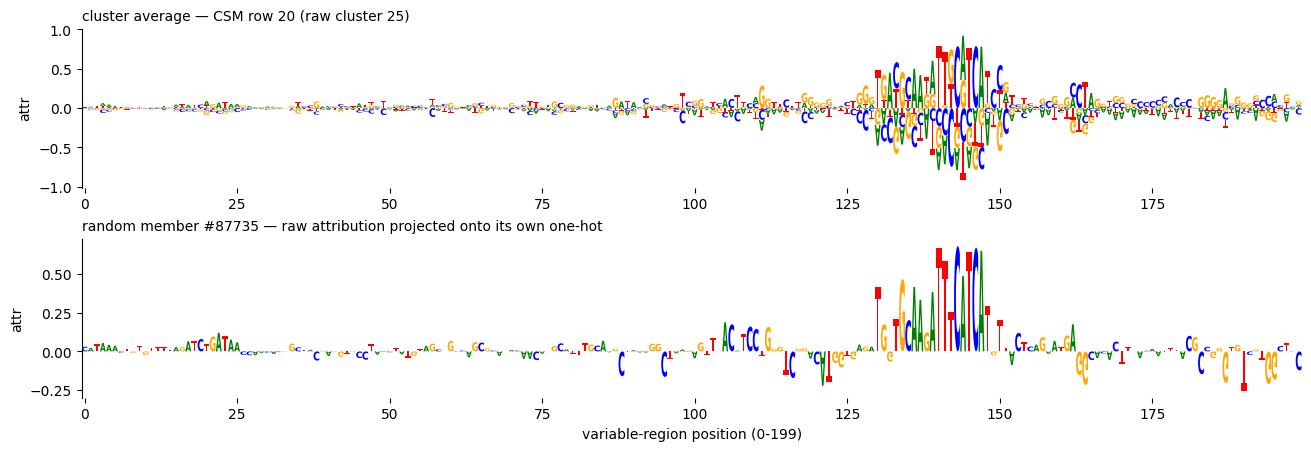

In [263]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 20  # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

CSM row 16 (sorted by median activity, high→low)  ->  raw cluster 41
  size                  = 1249
  cosine to WT          = 0.6180
  functional diff (Δpred) = -1.0197   (cluster mean 0.7454 vs WT 1.7651)
  random member index   = 16167  (pred 0.6907)


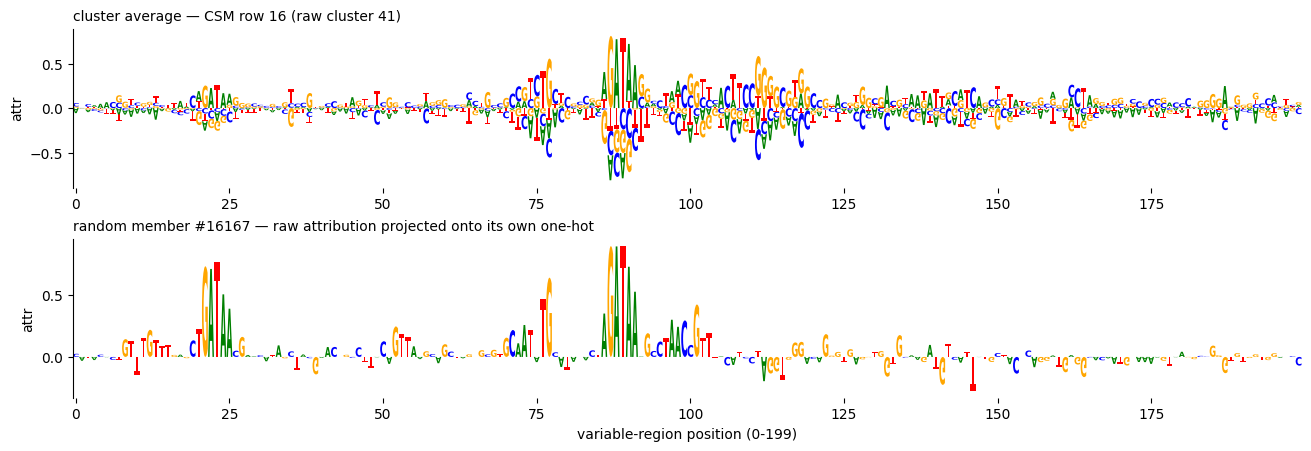

In [264]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 16  # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()

CSM row 49 (sorted by median activity, high→low)  ->  raw cluster 20
  size                  = 19832
  cosine to WT          = 0.4660
  functional diff (Δpred) = -2.2836   (cluster mean -0.5184 vs WT 1.7651)
  random member index   = 2740  (pred -0.5817)


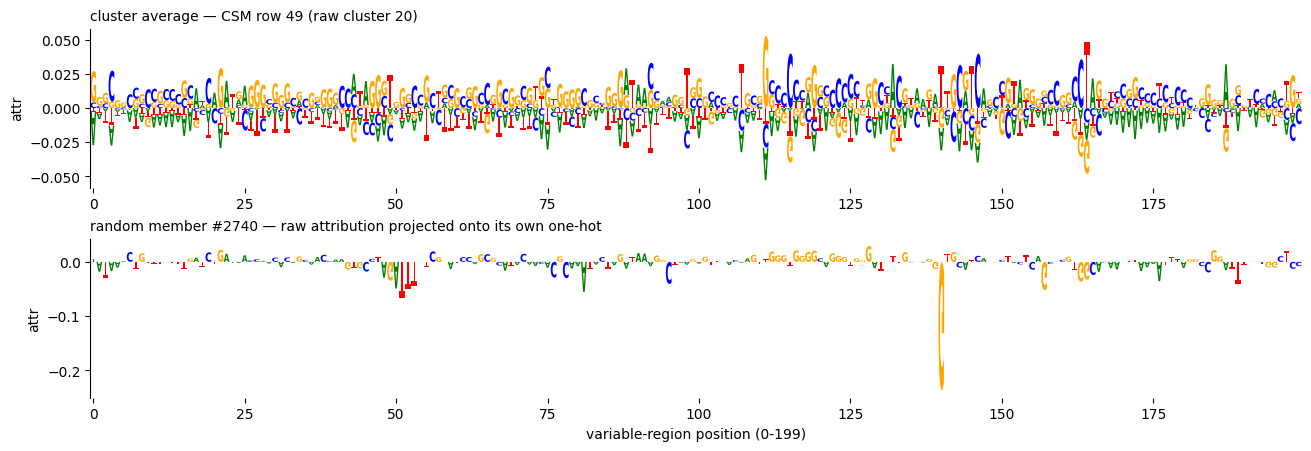

In [265]:
# Inspect one cluster by its SORTED CSM row (as read off the heatmap y-axis, top = row 0).
# Top logo: raw (200,4) cluster-average attribution. Bottom logo: ONE random cluster member's RAW
# attribution projected onto its OWN one-hot (no averaging — members have different sequences).
sel = 49  # <-- set to the CSM row you want to inspect

raw   = int(clusters_ord[sel])                 # original (raw) cluster id for this sorted row
m     = labels == raw
cavg  = att[m].mean(0)                          # (200,4) cluster-average attribution map
cos   = float(cavg.ravel() @ wt_unit / np.linalg.norm(cavg.ravel()))   # cosine of cluster-avg map to WT
dpred = float(preds[m].mean() - wt_pred)       # functional difference (cluster mean prediction − WT)
print(f"CSM row {sel} (sorted by median activity, high→low)  ->  raw cluster {raw}")
print(f"  size                  = {int(m.sum())}")
print(f"  cosine to WT          = {cos:.4f}")
print(f"  functional diff (Δpred) = {dpred:+.4f}   (cluster mean {preds[m].mean():.4f} vs WT {wt_pred:.4f})")

j       = int(np.random.default_rng().choice(np.flatnonzero(m)))   # one random member of this cluster
onehot_j = seqs[j, VAR_START:VAR_END].astype(np.float32)           # that member's own one-hot
proj_j   = att[j].astype(np.float32) * onehot_j                    # raw member attribution × its own one-hot
print(f"  random member index   = {j}  (pred {float(preds[j]):.4f})")

fig, axes = plt.subplots(2, 1, figsize=(13, 4.4), constrained_layout=True)
fast_logo(cavg.astype(np.float32), axes[0]);  strip_spines(axes[0])
axes[0].set_title(f"cluster average — CSM row {sel} (raw cluster {raw})", fontsize=10, loc="left")
fast_logo(proj_j, axes[1]);                   strip_spines(axes[1])
axes[1].set_title(f"random member #{j} — raw attribution projected onto its own one-hot", fontsize=10, loc="left")
for ax in axes:
    ax.set_ylabel("attr")
axes[-1].set_xlabel("variable-region position (0-199)")
plt.show()